# Puzzle

https://thefiddler.substack.com/p/can-you-fit-the-stars-on-the-flag

# Solution

I used desmos to play around with this problem, and that was really fun.

https://www.desmos.com/calculator/hrlwvfig3k

I estimate that the Fiddler answer is 14, and the EC answer is about 4.16.

But for greater confidence and precision, I am going to write some code for this.

### Fiddler
R is the radius.

p,q is the center.

Because of the regularity of the grid, we can limit p,q to the range 0 to 1.
And because of the reflection symmetries, we can limit our search to 0 <= q <= p <= 0.5

But I'll search the range 0 <= q, p <= 0.5 for simplicity of coding.

In [32]:
from math import ceil
def count_stars(R, p, q):
    count = 0
    S=ceil(R + max(p,q))
    R_sq = R*R
    for x in range(-S, S+1):
        x_sq = (x-p)*(x-p)
        for y in range(-S, S+1):
            y_sq = (y-q)*(y-q)
            if x_sq + y_sq <= R_sq:
                count += 1
    return count

assert(count_stars(2, 0, 0) == 13)
assert(count_stars(2, 0.5, 0.1) == 14)


If we have radius R, then we have to consider about (2R)^2 points. Drawing a circle of radius R around each of those points will mark the region where center point locations will include that point.

Some of these circles will cut through our p-q region of interest, and partition it.

Since we have 4R^2 circles, we can have at most 4R^2 cuts in the x and y directions. So, I think it should suffice to sample the p-q space with a grid with 4R^2 points along each axis. I'll do something higher to be safe, but I don't think we need to search infinitely finely.

In [33]:
def find_max_stars(R, safety_factor=2):
    max_stars = 0
    S=ceil(R)
    pq_steps = (2*S*safety_factor)**2
    best_p, best_q = 0, 0
    pq_step = 0.5/pq_steps
    for pi in range(0, pq_steps+1):
        p = pi * pq_step
        for qi in range(0, pi+1):
            q = qi * pq_step
            stars = count_stars(R, p, q)
            if stars > max_stars:
                max_stars = stars
                best_p, best_q = p, q
    return max_stars, best_p, best_q

find_max_stars(2)

(14, 0.34375, 0.1171875)

Fiddler Answer seems to be correct.

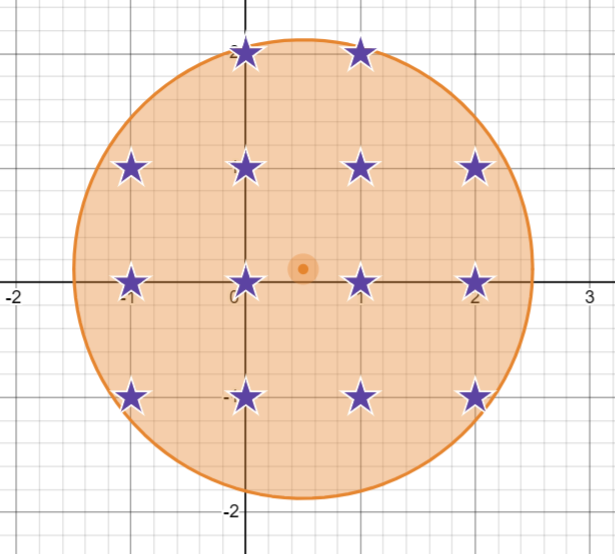

### Extra Credit

In [34]:
def find_lowest_R(desired_count, safety_factor=2, precision=1e-6, details=False):
    R = 1
    while True:
        max_stars, _, _ = find_max_stars(R, safety_factor)
        if details:
            print(f"Trying R={R}: max_stars={max_stars}")
        if max_stars >= desired_count:
            break
        else:
            R += 1
    # Now we have an upper bound for R, let's do a binary search to find the lowest R
    low, high = R-1, R
    if details:
        print(f"Initial bounds for R: low={low}, high={high}")
    while high - low > precision:
        mid = (low + high) / 2
        mid_stars, _, _ = find_max_stars(mid, safety_factor)
        if details:
            print(f"Checking R={mid}: max_stars={mid_stars}")
        if mid_stars >= desired_count:
            high = mid
        else:
            low = mid

    return high

find_lowest_R(14, details=False)

1.9028053283691406

In [35]:
find_lowest_R(58, precision=1e-8, details=True)

Trying R=1: max_stars=5
Trying R=2: max_stars=14
Trying R=3: max_stars=32
Trying R=4: max_stars=52
Trying R=5: max_stars=81
Initial bounds for R: low=4, high=5
Checking R=4.5: max_stars=69
Checking R=4.25: max_stars=61
Checking R=4.125: max_stars=57
Checking R=4.1875: max_stars=58
Checking R=4.15625: max_stars=58
Checking R=4.140625: max_stars=57
Checking R=4.1484375: max_stars=57
Checking R=4.15234375: max_stars=57
Checking R=4.154296875: max_stars=57
Checking R=4.1552734375: max_stars=58
Checking R=4.15478515625: max_stars=57
Checking R=4.155029296875: max_stars=57
Checking R=4.1551513671875: max_stars=57
Checking R=4.15521240234375: max_stars=58
Checking R=4.155181884765625: max_stars=57
Checking R=4.1551971435546875: max_stars=58
Checking R=4.155189514160156: max_stars=57
Checking R=4.155193328857422: max_stars=58
Checking R=4.155191421508789: max_stars=57
Checking R=4.1551923751831055: max_stars=57
Checking R=4.155192852020264: max_stars=58
Checking R=4.155192613601685: max_stars=

4.155192539095879

EC answer also seems correct.

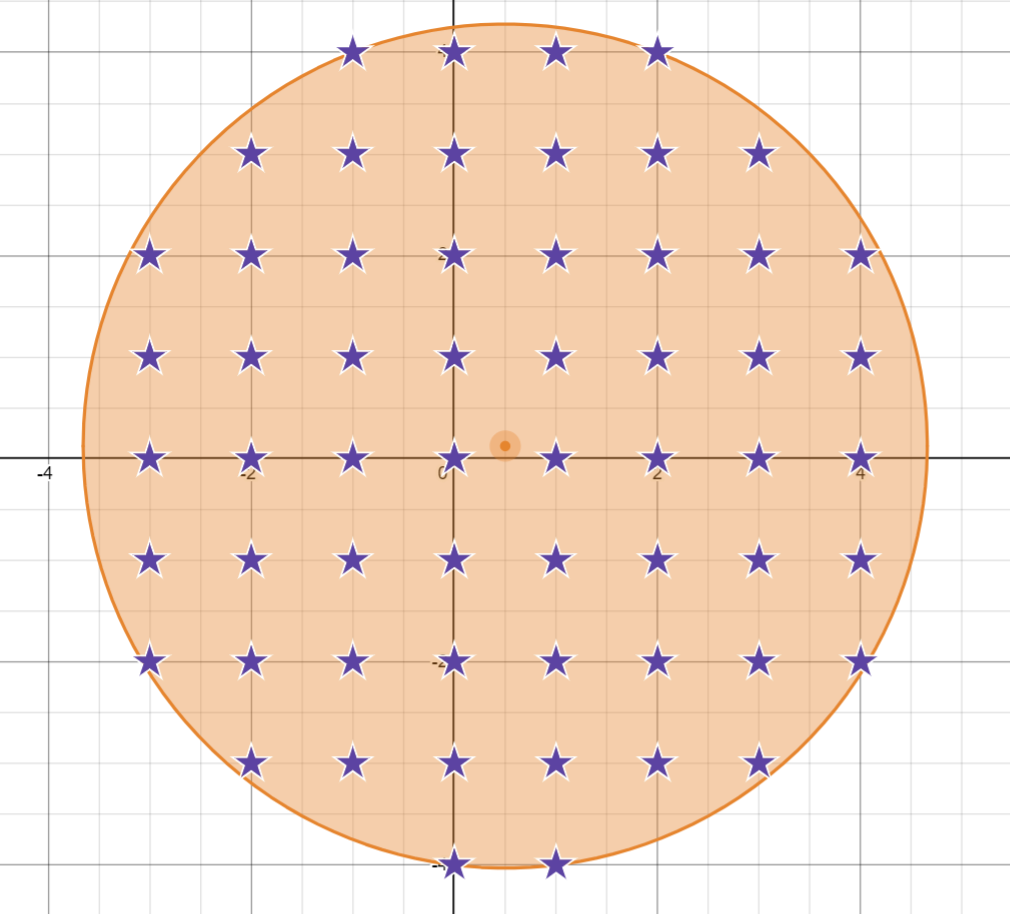

# Conclusion

Fiddler Answer is 14.

EC Answer is 4.15519254